# Lab03 - Regresión logística desde cero

## Objetivo

En este laboratorio voy a implementar regresión logística desde cero usando Python y NumPy.

El objetivo será construir un modelo que estime si un estudiante aprueba o no un examen a partir de sus horas de estudio.

A diferencia de la regresión lineal, donde el modelo predice un valor numérico continuo, en este caso la salida será binaria:

- `0` = no aprobó
- `1` = aprobó

Para construir el dataset, primero se definirá un puntaje de examen para cada estudiante. Luego, se transformará ese puntaje en una variable binaria usando la siguiente regla:

- si el puntaje es mayor o igual a 60, el estudiante aprobó (`1`)
- si el puntaje es menor que 60, el estudiante no aprobó (`0`)

Aunque el puntaje se usará para construir la variable objetivo, el modelo de regresión logística usará como entrada solamente las horas de estudio.

Es decir, el modelo no intentará predecir el puntaje exacto del examen, sino la probabilidad de aprobar.

## Etapa 0 - Presentación del problema y del dataset

En esta etapa se define un dataset simple para estudiar el comportamiento de la regresión logística.

Cada fila representa un estudiante.

Las variables iniciales serán:

- `horas_estudio`: cantidad de horas de estudio
- `puntajes`: puntaje obtenido en el examen

A partir de `puntajes`, se construirá la variable objetivo:

- `y_train`: resultado binario del examen

Donde:

- `0` = no aprobó
- `1` = aprobó

La regla para construir `y_train` será:

- si el puntaje es mayor o igual a 60, el estudiante aprobó (`1`)
- si el puntaje es menor que 60, el estudiante no aprobó (`0`)

El problema de aprendizaje será:

> Dadas las horas de estudio de un estudiante, estimar la probabilidad de que apruebe el examen.

Este es un problema de clasificación binaria porque la salida posible tiene solo dos valores: aprobó o no aprobó.

Aunque en la vida real el resultado podría depender de muchas otras variables, en este laboratorio se usará una sola variable de entrada para mantener el ejemplo simple y poder implementar la regresión logística desde cero paso a paso.

### Consigna

Crear los arreglos iniciales de NumPy:

- `horas_estudio`: cantidad de horas estudiadas
- `puntajes`: puntaje obtenido en el examen

A partir de ellos, definir:

- `x_train`: variable de entrada del modelo, usando `horas_estudio`
- `y_train`: variable objetivo, usando el resultado binario de aprobación

La variable `y_train` debe construirse aplicando la regla:

```python
puntajes >= 60
```
Finalmente, mostrar el dataset para verificar que los datos fueron cargados correctamente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

horas_estudio = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
puntajes = np.array([42, 48, 51, 55, 58, 61, 57, 66, 72, 78, 84, 90])

In [2]:
x_train = horas_estudio
y_train = (puntajes >= 60).astype(int)
print(f"variable objetivo: {y_train}")

variable objetivo: [0 0 0 0 0 1 0 1 1 1 1 1]


In [3]:
print("+------------------+---------+--------+")
print("| Horas de estudio | Puntaje | Aprobó |")

for horas, puntaje, aprobo in zip(horas_estudio, puntajes, y_train):
    print("|------------------+---------+--------|")
    print(f"|{horas:17.1f} | {puntaje:7d} | {aprobo:7d}|")

print("+------------------+---------+--------+")

+------------------+---------+--------+
| Horas de estudio | Puntaje | Aprobó |
|------------------+---------+--------|
|              0.5 |      42 |       0|
|------------------+---------+--------|
|              1.0 |      48 |       0|
|------------------+---------+--------|
|              1.5 |      51 |       0|
|------------------+---------+--------|
|              2.0 |      55 |       0|
|------------------+---------+--------|
|              2.5 |      58 |       0|
|------------------+---------+--------|
|              3.0 |      61 |       1|
|------------------+---------+--------|
|              3.5 |      57 |       0|
|------------------+---------+--------|
|              4.0 |      66 |       1|
|------------------+---------+--------|
|              4.5 |      72 |       1|
|------------------+---------+--------|
|              5.0 |      78 |       1|
|------------------+---------+--------|
|              5.5 |      84 |       1|
|------------------+---------+--------|


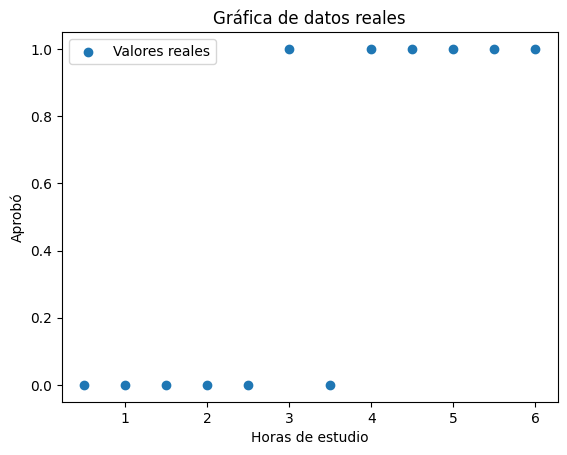

In [4]:
plt.scatter(x_train, y_train, label="Valores reales")
plt.legend()
plt.title("Gráfica de datos reales")
plt.xlabel("Horas de estudio")
plt.ylabel("Aprobó")
plt.show()

## Etapa 1 - Función lineal y función sigmoide

En regresión logística, primero se calcula una función lineal:

```python
z = w * x + b
```

Esta parte es similar a la regresión lineal.

Donde:

- `x` es la variable de entrada
- `w` es el peso o pendiente
- `b` es el sesgo o intercepto
- `z` es el resultado lineal antes de aplicar la función sigmoide

Sin embargo, en regresión logística no usamos directamente `z` como predicción final, porque `z` puede tomar cualquier valor: negativo, cero o positivo.

Como queremos estimar una probabilidad, necesitamos transformar `z` a un valor entre `0` y `1`.

Para eso usamos la función sigmoide:

```python
g(z) = 1 / (1 + e^(-z))
```

La función sigmoide convierte cualquier valor real en un número entre `0` y `1`.

Esto permite interpretar la salida como una probabilidad:

- valores cercanos a `0` indican baja probabilidad de aprobar
- valores cercanos a `1` indican alta probabilidad de aprobar
- el valor `0.5` representa el punto de decisión intermedio


In [5]:
def f_wb(x, w, b):
    return w * x + b
    
def sigmoidea(x, w, b):
    z = f_wb(x, w, b)
    gz = 1 / (1 + np.exp(-z))
    return gz

In [6]:
print(f"Salida de función sigmoidea: {sigmoidea(3,1,0)}")

Salida de función sigmoidea: 0.9525741268224334


Para observar la forma de la función sigmoide, podemos graficarla usando varios valores posibles de `z`.


La línea:

```python
z_valores = np.linspace(-10, 10, 100)
```

crea 100 valores entre `-10` y `10`.

Luego, para cada valor de `z`, se calcula su valor correspondiente en la función sigmoide.

En el gráfico se observa que la función sigmoide tiene forma de "S".

Cuando `z` toma valores negativos grandes, la función se acerca a `0`.

Cuando `z = 0`, la función vale `0.5`.

Cuando `z` toma valores positivos grandes, la función se acerca a `1`.

Por eso la función sigmoide es útil en problemas de clasificación binaria: transforma el resultado lineal `z` en una salida interpretable como probabilidad.

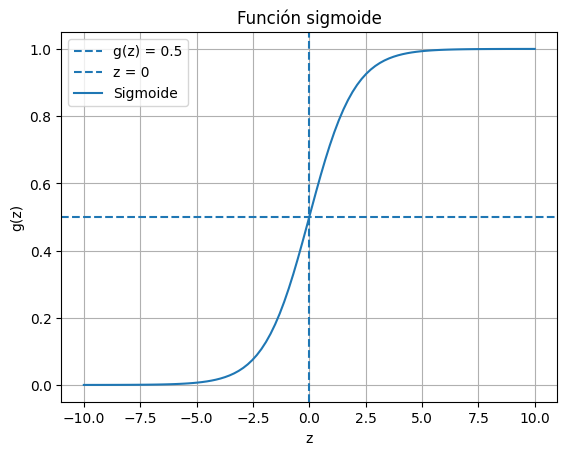

In [7]:
z_valores = np.linspace(-10, 10, 100)
g_valores = 1 / (1 + np.exp(-z_valores))

plt.axhline(y=0.5, linestyle="--", label="g(z) = 0.5")
plt.axvline(x=0, linestyle="--", label="z = 0")

plt.plot(z_valores, g_valores, label="Sigmoide")
plt.xlabel("z")
plt.ylabel("g(z)")
plt.legend()
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

## Etapa 2 - Función de coste

Una vez definida la función sigmoide, necesitamos una forma de medir qué tan bien está prediciendo el modelo.

La función de coste compara las probabilidades estimadas por el modelo contra los valores reales de `y_train`.

En regresión logística no usamos el error cuadrático como función principal de coste, sino una función basada en logaritmos.

La función de coste para regresión logística es:

$J(w,b) = -\frac{1}{m} \sum \left[ y \log(f) + (1-y)\log(1-f) \right]$



In [8]:
def J_wb(x, y, w, b):
    m = len(x)
    suma = 0

    for i in range(m):
        f = sigmoidea(x[i], w, b)
        suma = suma + y[i] * np.log(f) + (1 - y[i]) * np.log(1 - f)
        
    return -1/m * (suma)

In [9]:
print(f"Salida de función de coste: {J_wb(x_train, y_train, 1, 0)}")
print(f"Salida de función de coste: {J_wb(x_train, y_train, 0, 0)}")

Salida de función de coste: 1.026281217877232
Salida de función de coste: 0.6931471805599452


## Etapa 3 - Derivadas parciales

Para poder ajustar los parámetros `w` y `b`, necesitamos calcular cómo cambia la función de coste cuando cambia cada parámetro.

Las derivadas parciales indican la dirección en la que debe modificarse cada parámetro para reducir el coste.

Para regresión logística, las derivadas son:

$
\frac{\partial J}{\partial w} =
\frac{1}{m} \sum_{i=0}^{m-1}
\left(g(z^{(i)}) - y^{(i)}\right)x^{(i)}
$

$
\frac{\partial J}{\partial b} =
\frac{1}{m} \sum_{i=0}^{m-1}
\left(g(z^{(i)}) - y^{(i)}\right)
$

Donde:

- $g(z^{(i)})$ representa la probabilidad estimada por la función sigmoide.
- `y` es el valor real
- `x` es la variable de entrada

Estas derivadas se usarán luego en el descenso de gradiente.

In [10]:
def derivada_parcial_w(x, y, w, b):
    m = len (x)
    suma = 0

    for i in range(m):
        f = sigmoidea(x[i], w, b)
        suma = suma + (f - y[i]) * x[i]
        
    return 1/m * (suma)

def derivada_parcial_b(x, y, w, b):
    m = len(x)
    suma = 0

    for i in range(m):
        f = sigmoidea(x[i], w, b)
        suma = suma + (f - y[i]) 
        
    return 1/m * (suma)    

## Etapa 4 - Descenso de gradiente

El descenso de gradiente es el algoritmo que ajusta los parámetros `w` y `b`.

En cada iteración:

1. Se calcula la predicción del modelo.
2. Se calcula el error respecto a los valores reales.
3. Se calculan las derivadas parciales.
4. Se actualizan `w` y `b` en la dirección que reduce el coste.
5. Se vuelve a calcular el coste.

Las actualizaciones son:

```python
w = w - alfa * dj_dw
b = b - alfa * dj_db
```

Donde:

- `alfa` es la tasa de aprendizaje
- `dj_dw` es la derivada parcial del coste respecto a `w`
- `dj_db` es la derivada parcial del coste respecto a `b`

Una tasa de aprendizaje muy chica puede hacer que el entrenamiento sea lento. Una tasa demasiado grande puede hacer que el coste no baje correctamente.

In [11]:
def gradiente_regresion_logistica(x, y, w, b, alfa, max_iter):
    tol = 0.1

    iteraciones = 0
    costo = J_wb(x, y, w, b)
    historial_costos = [costo]
    historial_w = [w] #para grafica de contorno
    historial_b = [b] #para grafica de contorno
    
    while (costo > tol and iteraciones < max_iter):
        dj_dw = derivada_parcial_w(x, y, w, b)
        dj_db = derivada_parcial_b(x, y, w, b)
        
        w = w - alfa * dj_dw
        b = b - alfa * dj_db
        
        costo = J_wb(x, y, w, b)
        historial_costos.append(costo)
        historial_w.append(w)
        historial_b.append(b)
        iteraciones = iteraciones + 1
    return w, b, costo, iteraciones, historial_costos, historial_w, historial_b

In [12]:
w_final, b_final, costo_final, iteraciones, historial_costos, historial_w, historial_b = gradiente_regresion_logistica(
    x_train, 
    y_train, 
    0, 
    0, 
    1.0,
    2000
)

print(f"w final: {w_final}")
print(f"b final: {b_final}")
print(f"costo final: {costo_final}")
print(f"iteraciones: {iteraciones}")

w final: 2.6099164536483697
b final: -8.481545819244175
costo final: 0.20921196593966263
iteraciones: 2000


### Elección de la tasa de aprendizaje

La tasa de aprendizaje, representada por `alfa`, controla el tamaño de los pasos que da el descenso de gradiente al actualizar los parámetros `w` y `b`.

Si `alfa` es muy chica, el coste baja lentamente y el algoritmo necesita muchas iteraciones.

Si `alfa` es demasiado grande, el algoritmo puede volverse inestable y el coste puede dejar de bajar correctamente.

En este laboratorio se prueban distintos valores de `alfa` para observar cómo cambia la velocidad de aprendizaje.

También es importante notar que el coste no necesariamente puede llegar a cero. En este dataset hay un caso con cierto ruido: un estudiante con `3.0` horas aprobó, mientras que otro con `3.5` horas no aprobó. Como el modelo usa una sola variable de entrada, no puede separar perfectamente todos los casos.

Por eso, el objetivo no es llegar a coste cero, sino reducir el coste y obtener parámetros que produzcan probabilidades razonables.

In [13]:
alfas = [0.1, 0.5, 1.0, 2.0]

for alfa in alfas:
    w_tmp, b_tmp, costo_tmp, iter_tmp, historial_costos_tmp, historial_w_tmp, historial_b_tmp = gradiente_regresion_logistica(
        x_train,
        y_train,
        0,
        0,
        alfa,
        2000
    )

    print(f"alfa: {alfa}")
    print(f"  w final: {w_tmp}")
    print(f"  b final: {b_tmp}")
    print(f"  costo final: {costo_tmp}")
    print(f"  iteraciones: {iter_tmp}")
    print()

alfa: 0.1
  w final: 1.934251988205962
  b final: -6.181490783590346
  costo final: 0.2189435264230269
  iteraciones: 2000

alfa: 0.5
  w final: 2.5491526146105685
  b final: -8.275855661550743
  costo final: 0.20928109339276002
  iteraciones: 2000

alfa: 1.0
  w final: 2.6099164536483697
  b final: -8.481545819244175
  costo final: 0.20921196593966263
  iteraciones: 2000

alfa: 2.0
  w final: 2.6150063580793974
  b final: -8.498767307723439
  costo final: 0.20921155646551853
  iteraciones: 2000



En esta prueba, los valores `0.5`, `1.0` y `2.0` logran costes finales muy similares luego de 2000 iteraciones.

El valor `0.1` aprende más lentamente.

Aunque `alfa = 2.0` obtiene un coste levemente menor en esta corrida, la diferencia con `alfa = 1.0` es muy pequeña. 

### Entrenamiento final con alfa elegida

In [14]:
alfa_elegido = 0.1

w_final, b_final, costo_final, iteraciones_finales, historial_costos, historial_w, historial_b = gradiente_regresion_logistica(
        x_train,
        y_train,
        0,
        0,
        alfa_elegido,
        2000
    )
print(f"w final: {w_final}")
print(f"b final: {b_final}")
print(f"coste final: {costo_final}")
print(f"iteraciones: {iteraciones_finales}")

w final: 1.934251988205962
b final: -6.181490783590346
coste final: 0.2189435264230269
iteraciones: 2000


### Evolución del coste durante el descenso de gradiente

En esta gráfica se observa cómo cambia el valor de la función de coste durante el entrenamiento.

Al comienzo, el coste es más alto porque los parámetros `w` y `b` todavía no fueron ajustados.

En cada iteración, el descenso de gradiente actualiza los parámetros buscando reducir el coste.

Si el algoritmo está funcionando correctamente, la curva debería mostrar una tendencia descendente.

En este caso, el coste baja desde su valor inicial hasta un valor menor, lo que indica que el modelo está aprendiendo mejores parámetros.



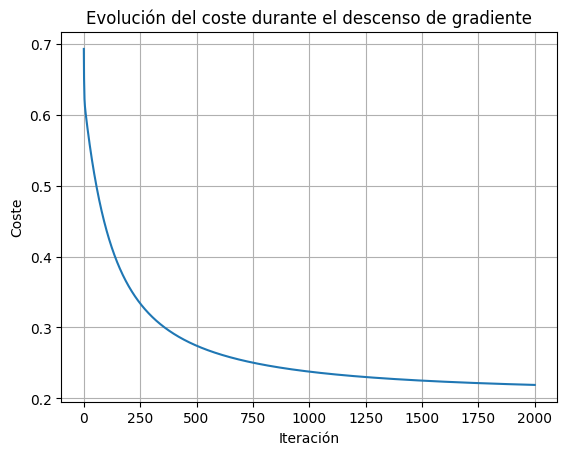

In [15]:
plt.plot(historial_costos)
plt.xlabel("Iteración")
plt.ylabel("Coste")
plt.title("Evolución del coste durante el descenso de gradiente")
plt.grid(True)
plt.show()

## Etapa 5 - Visualización de la función de coste con curvas de contorno

Hasta ahora se entrenó el modelo usando descenso de gradiente y se observó cómo baja el coste durante las iteraciones.

Otra forma útil de visualizar el problema es graficar la función de coste para distintos valores posibles de `w` y `b`.

Como el modelo tiene dos parámetros:

```python
z = w * x + b
```

podemos calcular el coste para muchas combinaciones de `w` y `b`.

Luego, usando un gráfico de contornos, se puede observar qué zonas tienen mayor o menor coste.

En este gráfico:

- el eje X representa posibles valores de `w`
- el eje Y representa posibles valores de `b`
- las curvas representan niveles de coste similares
- las zonas de menor coste indican mejores combinaciones de parámetros

Este tipo de gráfico ayuda a entender visualmente qué está intentando hacer el descenso de gradiente.

In [16]:
def graficar_contornos_coste(x, y, w_min, w_max, b_min, b_max, historial_w, historial_b, cantidad_puntos=100):
    w_valores = np.linspace(w_min, w_max, cantidad_puntos)
    b_valores = np.linspace(b_min, b_max, cantidad_puntos)

    W, B = np.meshgrid(w_valores, b_valores)
    Z = np.zeros(W.shape)

    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Z[i, j] = J_wb(x, y, W[i, j], B[i, j])

    
    hist_w = np.array(historial_w)
    hist_b = np.array(historial_b)
    
    # Mostrar solo algunos pasos del camino
    indices = np.linspace(0, len(hist_w) - 1, 12, dtype=int)
    
    plt.contour(W, B, Z, levels=30)
    
    plt.plot(
        hist_w[indices],
        hist_b[indices],
        marker="o",
        linewidth=2,
        label="Camino del gradiente"
    )
    
    # flechas entre esos puntos seleccionados
    for i in range(len(indices) - 1):
        idx_actual = indices[i]
        idx_siguiente = indices[i + 1]
    
        plt.annotate(
            "",
            xy=(hist_w[idx_siguiente], hist_b[idx_siguiente]),
            xytext=(hist_w[idx_actual], hist_b[idx_actual]),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )
    
    plt.scatter(hist_w[0], hist_b[0], marker="s", s=90, label="Inicio")
    plt.scatter(hist_w[-1], hist_b[-1], marker="X", s=120, label="Final")
    
    plt.xlabel("w")
    plt.ylabel("b")
    plt.title("Curvas de contorno y camino del descenso de gradiente")
    plt.grid(True)
    plt.legend()
    plt.show()
    

### Nota sobre la visualización del camino del descenso de gradiente

El descenso de gradiente puede realizar muchas actualizaciones pequeñas de los parámetros `w` y `b`.

Si se grafican todos los puntos del recorrido, estos pueden quedar demasiado juntos, haciendo que la visualización se vea como una mancha y sea difícil de interpretar.

Para mejorar la claridad del gráfico, se selecciona un subconjunto de puntos representativos del recorrido completo.

Esto se logra utilizando la siguiente instrucción:

`indices = np.linspace(0, len(hist_w) - 1, 12, dtype=int)`

Esta instrucción genera 12 posiciones distribuidas a lo largo de todo el historial del descenso de gradiente.

Luego, se utilizan esos índices para graficar únicamente esos puntos y dibujar flechas entre ellos, mostrando de forma más clara la dirección del movimiento.

De esta manera, la gráfica permite visualizar mejor:

- el punto de inicio del algoritmo;
- la trayectoria que siguen los parámetros `w` y `b`;
- la dirección del descenso;
- el punto final alcanzado;
- cómo el algoritmo se aproxima progresivamente a una zona de menor coste.

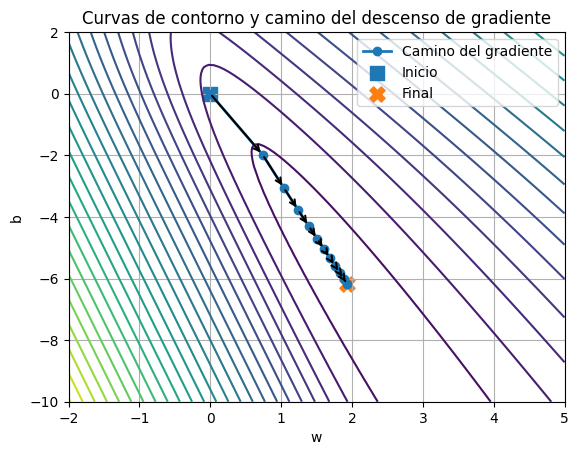

In [17]:
graficar_contornos_coste(
    x_train,
    y_train,
    w_min=-2,
    w_max=5,
    b_min=-10,
    b_max=2,
    historial_w=historial_w,
    historial_b=historial_b,
    cantidad_puntos=100
)

En el gráfico de contornos se observa cómo cambia el coste para distintas combinaciones de `w` y `b`.

Cada curva representa un conjunto de puntos con valores similares de coste.

El camino marcado muestra cómo se fueron actualizando `w` y `b` durante el descenso de gradiente. El punto inicial indica los parámetros antes del entrenamiento y el punto final indica los parámetros obtenidos al terminar.

Si el entrenamiento funcionó correctamente, ese punto debería ubicarse en una zona de bajo coste.

Este gráfico permite visualizar que el entrenamiento no busca ajustar directamente los puntos del dataset, sino encontrar los valores de `w` y `b` que minimizan la función de coste.

In [18]:
probabilidades_estimadas = sigmoidea(x_train, w_final, b_final)

umbral = 0.5
clasificaciones_estimadas = (probabilidades_estimadas >= umbral).astype(int)

print("+------------------+------------------------+-------------------------+------------+")
print("| Horas de estudio | Probabilidad estimada  | Clasificación estimada  | Valor real |")
print("+------------------+------------------------+-------------------------+------------+")

for horas, probabilidad, clasificacion, real in zip(
    x_train, 
    probabilidades_estimadas, 
    clasificaciones_estimadas, 
    y_train
):
    print(f"|{horas:17.1f} | {probabilidad:22.4f} | {clasificacion:23d} | {real:10d} |")

print("+------------------+------------------------+-------------------------+------------+")

+------------------+------------------------+-------------------------+------------+
| Horas de estudio | Probabilidad estimada  | Clasificación estimada  | Valor real |
+------------------+------------------------+-------------------------+------------+
|              0.5 |                 0.0054 |                       0 |          0 |
|              1.0 |                 0.0141 |                       0 |          0 |
|              1.5 |                 0.0363 |                       0 |          0 |
|              2.0 |                 0.0901 |                       0 |          0 |
|              2.5 |                 0.2065 |                       0 |          0 |
|              3.0 |                 0.4064 |                       0 |          1 |
|              3.5 |                 0.6430 |                       1 |          0 |
|              4.0 |                 0.8257 |                       1 |          1 |
|              4.5 |                 0.9257 |                    

En la tabla se compara, para cada estudiante:

- las horas de estudio
- la probabilidad estimada de aprobar
- la clasificación estimada usando el umbral `0.5`
- el valor real observado en el dataset

El modelo logra estimar probabilidades bajas para estudiantes con pocas horas de estudio y probabilidades altas para estudiantes con más horas.

Sin embargo, no clasifica correctamente todos los casos. Esto es esperable porque el dataset tiene un caso con ruido:

```text
3.0 horas  → aprobó
3.5 horas  → no aprobó
```

Como el modelo usa una sola variable de entrada, no puede separar perfectamente esos dos casos.

Aun así, el comportamiento general del modelo es razonable: a medida que aumentan las horas de estudio, aumenta la probabilidad estimada de aprobar.

## Conclusión

En este laboratorio se implementó regresión logística desde cero usando Python y NumPy.

El proceso completo incluyó:

- construir una variable objetivo binaria a partir de puntajes de examen
- definir la función lineal `z = w * x + b`
- aplicar la función sigmoide para obtener probabilidades
- implementar la función de coste de regresión logística
- calcular las derivadas parciales respecto a `w` y `b`
- aplicar descenso de gradiente para ajustar los parámetros
- comparar distintos valores de la tasa de aprendizaje `alfa`
- visualizar la evolución del coste durante el entrenamiento
- graficar curvas de contorno de la función de coste
- calcular probabilidades y clasificaciones estimadas con el modelo entrenado

El modelo aprendió una relación coherente: a mayor cantidad de horas de estudio, mayor probabilidad estimada de aprobar.

También se observó que el coste no llega a cero porque el dataset no es perfectamente separable usando solamente una variable de entrada.